# Instance Impact Framework: Full-Pipeline Case Study Notebook

## Objective
This notebook executes and presents the **entire packaged pipeline** from raw pre/post input images to instance-level impact outputs.
You should expect per-building outputs from each stage: Stage 1 instance polygons with segmentation confidence, Stage 2a exposure signals (predicted population and building type), and Stage 2b damage predictions with calibrated confidence and uncertainty metrics.
The notebook culminates in a merged instance table, uncertainty-ranked cases, and polygon overlays that make each prediction interpretable in its visual context.

## Pipeline
`Stage1 -> shared subimages -> Stage2a -> Stage2b -> presentation -> overlay`

![Instance Impact Conceptualization](II-Conceptualization.png)`

## Assumptions
- Environment is prepared from package dependencies.
- Input pre/post images are valid and correspond to the same tile.
- The notebook is run top-to-bottom without skipping cells.

## Scope
- Inference + presentation only (no training).
- Structured for server-kernel execution with reproducible paths and commands.

## 0.5) GeoAI Kernel Bootstrap (One-Time User-Site Setup)

Run this once **before** the pipeline cells when you are on the managed `geoai` kernel and need Stage 1 (`samgeo` + `Sam3Model`) to work.

### Why this exists
- The base kernel in `/cvmfs/.../geoai` is read-only.
- We encountered a concrete package collision: user-site `numpy 2.x` shadowed base `numpy 1.26.4`, which broke imports with `libscipy_openblas64_-ff84a88b.so` errors and cascaded into `pandas/scipy/torch/rasterio` failures.
- We install a compatible, pinned override set into writable user site `/home/jovyan/.local/geoai` to keep the runtime stable.
- This notebook expects those user-site packages to be present.

### Terminal commands (exact sequence used in this recovery)

#### Optional: purge/reset user-site profile (if environment gets corrupted)
```bash
# backup current profile first (safe rollback)
mv /home/jovyan/.local/geoai /home/jovyan/.local/geoai_backup_$(date +%Y%m%d_%H%M%S)
mkdir -p /home/jovyan/.local/geoai

# then run the bootstrap commands above from step 1
```

```bash
# 1) Target the managed geoai interpreter and user profile
export PYTHONUSERBASE=/home/jovyan/.local/geoai
GEOAI_PY=/cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python

# 2) Upgrade packaging tools in user-site
$GEOAI_PY -m pip install --user --upgrade pip setuptools wheel

# 3) Keep numeric stack stable (avoid numpy 2.x ABI churn)
$GEOAI_PY -m pip install --user "numpy==1.26.4" "opencv-python-headless==4.10.0.84"

# 4) Install base runtime pieces (no dependency backtracking)
$GEOAI_PY -m pip install --user --no-deps \
  timm==1.0.25 \
  segment-anything \
  segment-geospatial \
  geoai-py \
  geopandas

# 5) Upgrade torch stack in user-site (CPU wheels in this platform run)
$GEOAI_PY -m pip install --user --index-url https://download.pytorch.org/whl/cpu \
  "torch==2.4.1" "torchvision==0.19.1" "torchaudio==2.4.1"

# 6) Install transformers from source branch (Sam3Model symbol required)
$GEOAI_PY -m pip install --user --upgrade --no-deps \
  "git+https://github.com/huggingface/transformers.git"

# 7) Patch missing runtime dependencies observed during import tests
$GEOAI_PY -m pip install --user --upgrade httpx
$GEOAI_PY -m pip install --user --upgrade "huggingface_hub>=0.30"
$GEOAI_PY -m pip install --user --upgrade "regex>=2025.10.22"
$GEOAI_PY -m pip install --user --upgrade tokenizers safetensors
```

### Validation (run in notebook)
```python
import site, numpy, torch, transformers
from transformers import Sam3Model
from samgeo import SamGeo3

print("user_site:", site.getusersitepackages())
print("numpy:", numpy.__version__, numpy.__file__)
print("torch:", torch.__version__, torch.__file__)
print("transformers:", transformers.__version__, transformers.__file__)
print("Sam3Model + SamGeo3 import: OK")
```

### Required after installation
1. **Restart the kernel** once installs finish.
2. Re-run notebook from the top.

### Notes
- Warnings like `.../home/jovyan/.local/geoai/bin is not on PATH` are expected and safe.
- Do **not** try to uninstall packages from `/cvmfs/...`; that filesystem is read-only.
- If Stage 1 OOMs, reduce Stage 1 batch size (`--batch-size 1` is the safest default).

### Core Imports

Load foundational Python modules for path handling, shell execution, and file operations.

In [1]:
from pathlib import Path
import os
import json
import shutil
import subprocess
import shlex
import sys

print("Base imports ready.")

Base imports ready.


### HF Token Setup (manual input required)

Configure optional secure `HF_TOKEN` input required for gated Stage1 model access.

In [2]:
# --- Token setup for Stage1 SAM3 access (public-safe) ---
import os
from getpass import getpass

if not os.environ.get("HF_TOKEN", "").strip():
    token = getpass("Enter HF_TOKEN (input hidden, leave blank to skip): ").strip()
    if token:
        os.environ["HF_TOKEN"] = token
        print("HF_TOKEN set for current kernel session.")
    else:
        print("HF_TOKEN not provided. Stage1 may fail if SAM3 model access is required.")
else:
    print("HF_TOKEN present in environment.")

Enter HF_TOKEN (input hidden, leave blank to skip):  ········


HF_TOKEN set for current kernel session.


### Case Configuration

Define package root, input image pair, run ID, and runtime configuration for this study.

In [3]:
# --- 1) Study configuration: full pipeline run ---

# Auto-locate package root (supports opening notebook from parent directory).
PACKAGE_ROOT = Path.cwd()
if not (PACKAGE_ROOT / "run_pipeline.sh").exists() and (PACKAGE_ROOT / "II_package" / "run_pipeline.sh").exists():
    PACKAGE_ROOT = PACKAGE_ROOT / "II_package"

# Input image pair (customize these two paths).
PRE_IMAGE = PACKAGE_ROOT / "example_image_pair" / "nepal-flooding_00000408_pre_disaster.png"
POST_IMAGE = PACKAGE_ROOT / "example_image_pair" / "nepal-flooding_00000408_post_disaster.png"

# Run identifier for outputs.
RUN_ID = "nb_full_pipeline_nepal_flooding_00000408"

# Runtime settings (aligned with package defaults).
PYTHON_BIN = sys.executable
CUDA_VISIBLE_DEVICES = "0"
VERBOSE_RUN = False

print("PACKAGE_ROOT:", PACKAGE_ROOT)
print("PRE_IMAGE:", PRE_IMAGE)
print("POST_IMAGE:", POST_IMAGE)
print("RUN_ID:", RUN_ID)
print("PYTHON_BIN:", PYTHON_BIN)

PACKAGE_ROOT: /home/jovyan/II_package
PRE_IMAGE: /home/jovyan/II_package/example_image_pair/nepal-flooding_00000408_pre_disaster.png
POST_IMAGE: /home/jovyan/II_package/example_image_pair/nepal-flooding_00000408_post_disaster.png
RUN_ID: nb_full_pipeline_nepal_flooding_00000408
PYTHON_BIN: /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python


### Run Directory Reset

Create a fresh output run directory to ensure reproducible notebook execution.

In [4]:
# --- 2) Prepare a clean run directory ---
# Environment is expected to be prepared in the active kernel user-site.
# This cell keeps runtime setup deterministic by resetting the run folder.

RUN_ROOT = PACKAGE_ROOT / "outputs" / "driver_runs"
RUN_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = RUN_ROOT / RUN_ID
if RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)
print("RUN_DIR (fresh):", RUN_DIR)

RUN_DIR (fresh): /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408


### Scientific Imports and Device Setup

Import scientific libraries and resolve CPU/GPU device targets for all stages.

In [5]:
# --- 2b) Scientific/runtime imports + device selection ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

STAGE1_DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
STAGE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("numpy:", np.__version__)
print("numpy path:", np.__file__)
print("torch:", torch.__version__)
print("cuda_available:", torch.cuda.is_available(), "count:", torch.cuda.device_count())
print("STAGE1_DEVICE:", STAGE1_DEVICE)
print("STAGE_DEVICE:", STAGE_DEVICE)
print("Scientific imports ready.")

numpy: 1.26.4
numpy path: /cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/numpy/__init__.py
torch: 2.4.1+cpu
cuda_available: False count: 0
STAGE1_DEVICE: cpu
STAGE_DEVICE: cpu
Scientific imports ready.


### Stage 1 Execution

Prepare input links and run SAM3-based building instance extraction on the pre-disaster image. On I-GUIDE CPU only device, ETA is ~10 min.

In [6]:
# --- 3a) Stage 1: execute ---

env = dict(os.environ)
env["PYTHON_BIN"] = PYTHON_BIN
env["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

def run_step(cmd, title):
    print(f"\n===== {title} =====")
    print("[cmd]", " ".join(shlex.quote(str(x)) for x in cmd))
    subprocess.run([str(x) for x in cmd], check=True, cwd=str(PACKAGE_ROOT), env=env)

tile_id = PRE_IMAGE.stem
if tile_id.endswith("_pre_disaster"):
    tile_id = tile_id[: -len("_pre_disaster")]

pair_dir = RUN_DIR / "pair_inputs"
pair_dir.mkdir(parents=True, exist_ok=True)
pre_link = pair_dir / f"{tile_id}_pre_disaster.png"
post_link = pair_dir / f"{tile_id}_post_disaster.png"
for dst in [pre_link, post_link]:
    if dst.exists() or dst.is_symlink():
        dst.unlink()
pre_link.symlink_to(PRE_IMAGE.resolve())
post_link.symlink_to(POST_IMAGE.resolve())

stage1_out = RUN_DIR / "stage1"
shared_out = RUN_DIR / "shared_instances_r48"
stage2a_input_csv = RUN_DIR / "stage2a_infer_input.csv"
stage2a_out_csv = RUN_DIR / "stage2a_predictions.csv"
stage2b_out_jsonl = RUN_DIR / "stage2b_ensemble.jsonl"
presented_csv = RUN_DIR / "instance_results_presented.csv"
uncertain_csv = RUN_DIR / "instance_results_top_uncertain.csv"
vis_dir = RUN_DIR / "vis_instance_level"

run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "stage1/SAM3_Final_20260226/scripts/run_sam3_building_infer.py",
        "--input", pair_dir,
        "--output", stage1_out,
        "--pattern", f"{tile_id}_pre_disaster.png",
        "--max-images", "1",
        "--prompt", "building",
        "--min-size", "30",
        "--output-style", "notebook",
        "--batch-size", "1",
        "--device", STAGE1_DEVICE,
        "--backend", "transformers",
        "--tile-size", "512",
        "--overlap", "64",
    ],
    "Stage 1: Building Instance Extraction",
)

label_dir = stage1_out / "labels"


===== Stage 1: Building Instance Extraction =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/II_package/stage1/SAM3_Final_20260226/scripts/run_sam3_building_infer.py --input /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/pair_inputs --output /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1 --pattern nepal-flooding_00000408_pre_disaster.png --max-images 1 --prompt building --min-size 30 --output-style notebook --batch-size 1 --device cpu --backend transformers --tile-size 512 --overlap 64


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


To use SamGeo 3, install it as:
	pip install segment-geospatial[samgeo3]
torch_version: 2.4.1+cpu
cuda_available: False
cuda_device_count: 0
Using cpu device and transformers backend


Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 2507.86it/s]
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/rasterio/__init__.py:314: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


Found 34 objects.
Saved 34 mask(s) to /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x0_y0_w512_h512.tif
Saved confidence scores to /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x0_y0_w512_h512_scores.tif
Found 14 objects.
Saved 14 mask(s) to /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x448_y0_w512_h512.tif
Saved confidence scores to /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tiles/masks/nepal-flooding_00000408_pre_disaster_x448_y0_w512_h512_scores.tif
No objects found. Please try a different prompt.
Found 25 objects.
Saved 25 mask(s) to /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/.tmp_tile

### Stage 1 Reporting

Verify Stage1 completion artifacts and count instance-level prediction JSON outputs.

In [7]:
# --- 3b) Stage 1: report ---
stage1_summary = stage1_out / "run_summary.json"
print("[stage1] run_summary_exists=", stage1_summary.exists())
print("[stage1] label_json_count=", len(list(label_dir.glob("*_prediction.json"))) )

[stage1] run_summary_exists= True
[stage1] label_json_count= 1


### Shared Subimage Generation

Create standardized per-instance crops and masks used by both Stage2a and Stage2b.

In [8]:
# --- 4a) Shared subimages: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/generate_shared_instance_subimages.py",
        "--stage1_labels_dir", label_dir,
        "--pre_images_dir", pair_dir,
        "--post_images_dir", pair_dir,
        "--out_root", shared_out,
        "--crop_size", "256",
        "--ring_radius_px", "48",
        "--strict_images",
        "--num_workers", "4",
        "--chunk_size", "100",
        "--log_every", "50",
    ],
    "Shared Subimage Generation",
)

shared_csv = shared_out / "shared_instance_samples.csv"


===== Shared Subimage Generation =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/II_package/scripts/generate_shared_instance_subimages.py --stage1_labels_dir /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage1/labels --pre_images_dir /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/pair_inputs --post_images_dir /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/pair_inputs --out_root /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48 --crop_size 256 --ring_radius_px 48 --strict_images --num_workers 4 --chunk_size 100 --log_every 50
Found Stage-1 label json files: 1
Loaded label files: 1
Collected rows: 113
Config: crop_size=256 ring_radius_px=48 polygon_source=pre_then_post dilate_backend=scipy num_workers=4 chunk_size=100
Prepared chunks: 2
progress 113/113 (100.0%) | written 113 | skip_i

### Shared Subimages Reporting

Check generated shared-instance table size and confidence statistics.

In [9]:
# --- 4b) Shared subimages: report ---
df_shared = pd.read_csv(shared_csv)
print("[shared] rows=", len(df_shared))
if "sam3_confidence" in df_shared.columns:
    x = pd.to_numeric(df_shared["sam3_confidence"], errors="coerce").dropna()
    if len(x) > 0:
        print("[shared] sam3_confidence median=", round(float(np.median(x)), 4))

[shared] rows= 113
[shared] sam3_confidence median= 0.6145


### Stage 2a Inference

Build Stage2a input CSV from shared artifacts and run type/population inference.

In [10]:
# --- 5a) Stage 2a: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/build_stage2a_infer_csv.py",
        "--shared_csv", shared_csv,
        "--out_csv", stage2a_input_csv,
        "--crop_col", "pre_crop",
        "--mask_col", "mask_M",
    ],
    "Stage 2a: Build Inference CSV",
)

run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/infer_stage2a.py",
        "--input_csv", stage2a_input_csv,
        "--ckpt", PACKAGE_ROOT / "models/stage2a/stage2a_best_model.pt",
        "--out_csv", stage2a_out_csv,
        "--batch_size", "4",
        "--num_workers", "4",
        "--device", STAGE_DEVICE,
        "--print_examples", "5",
    ],
    "Stage 2a: Population/Type Inference",
)

df_s2a = pd.read_csv(stage2a_out_csv)


===== Stage 2a: Build Inference CSV =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/II_package/scripts/build_stage2a_infer_csv.py --shared_csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48/shared_instance_samples.csv --out_csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_infer_input.csv --crop_col pre_crop --mask_col mask_M
[done] input_rows= 113
[done] output_rows= 113
[done] skipped_missing_paths= 0
[done] wrote= /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_infer_input.csv

===== Stage 2a: Population/Type Inference =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/II_package/scripts/infer_stage2a.py --input_csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_infer_input.csv --ckpt /home/jovyan/II_package/models/stage2a/s

/home/jovyan/II_package/scripts/infer_stage2a.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location="cpu")


[info] rows: 113
[info] device: cpu
[info] ckpt: /home/jovyan/II_package/models/stage2a/stage2a_best_model.pt
[infer_stage2a] step=20/29 done_rows=80
[done] wrote: /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_predictions.csv
[done] rows: 113
[summary] class_counts: {'commercial': 68, 'institutional': 45}
[summary] pred_population quantiles p0/p25/p50/p75/p95/p99: [44.565, 435.571, 851.511, 1279.746, 2440.444, 2961.628]
[examples] first_5:
   181eb0ca-d6e2-45c3-b4a9-4b742e29067f pop= 416.048 type= commercial conf= 0.521
   a19b5594-fc36-4496-b9d8-3e221b3495fe pop= 116.156 type= institutional conf= 0.5236
   1e07df51-2edc-4837-8c5e-b03bc6fe3bac pop= 2682.652 type= commercial conf= 0.8535
   12626fa5-c84a-4532-af08-9b9fd59e29e5 pop= 724.188 type= commercial conf= 0.529
   323a4e1b-31e5-4663-8ed0-871cd471fa11 pop= 1786.849 type= commercial conf= 0.7615


### Stage 2a Reporting

Summarize Stage2a prediction distribution and population quantiles.

In [11]:
# --- 5b) Stage 2a: report ---
print("[stage2a] rows=", len(df_s2a))
if "pred_type_class" in df_s2a.columns:
    print("[stage2a] type_counts=", df_s2a["pred_type_class"].value_counts().to_dict())
if "pred_population" in df_s2a.columns:
    p = pd.to_numeric(df_s2a["pred_population"], errors="coerce").dropna()
    if len(p) > 0:
        q = np.percentile(p, [50, 90, 99])
        print(f"[stage2a] population p50/p90/p99 = {q[0]:.2f}/{q[1]:.2f}/{q[2]:.2f}")

[stage2a] rows= 113
[stage2a] type_counts= {'commercial': 68, 'institutional': 45}
[stage2a] population p50/p90/p99 = 851.51/1780.95/2961.63


### Stage 2b Inference

Run calibrated ensemble damage inference and collect per-instance uncertainty outputs.

In [12]:
# --- 6a) Stage 2b: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/infer_stage2_ensemble.py",
        "--csv", shared_csv,
        "--ckpts", "models/stage2b/inference0.7273.pt,models/stage2b/inference0.7066_seed9999.pt,models/stage2b/inference0.7034_seed7777.pt",
        "--configs", "configs/stage2b/run019_seed2025_train_config.json,configs/stage2b/seed9999_train_config.json,configs/stage2b/seed7777_train_config.json",
        "--weights", "4,3,2",
        "--calibration_dirs", "calibration/calibration_run019_r48,calibration/calibration_seed9999_r48,calibration/calibration_seed7777_r48",
        "--calibration_method", "temperature",
        "--out_jsonl", stage2b_out_jsonl,
        "--batch_size", "2",
        "--num_workers", "4",
        "--device", STAGE_DEVICE,
        "--print_examples", "5",
        "--log_every_steps", "20",
    ],
    "Stage 2b: Damage/Uncertainty Inference",
)

rows_s2b = []
with stage2b_out_jsonl.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows_s2b.append(json.loads(line))


===== Stage 2b: Damage/Uncertainty Inference =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/II_package/scripts/infer_stage2_ensemble.py --csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48/shared_instance_samples.csv --ckpts models/stage2b/inference0.7273.pt,models/stage2b/inference0.7066_seed9999.pt,models/stage2b/inference0.7034_seed7777.pt --configs configs/stage2b/run019_seed2025_train_config.json,configs/stage2b/seed9999_train_config.json,configs/stage2b/seed7777_train_config.json --weights 4,3,2 --calibration_dirs calibration/calibration_run019_r48,calibration/calibration_seed9999_r48,calibration/calibration_seed7777_r48 --calibration_method temperature --out_jsonl /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2b_ensemble.jsonl --batch_size 2 --num_workers 4 --device cpu --print_examples 5 --log_every_steps 20


/home/jovyan/II_package/scripts/infer_stage2_ensemble.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


Loaded rows: 113
Device: cpu
Weights: [4.0, 3.0, 2.0]
Checkpoints:
 - models/stage2b/inference0.7273.pt
 - models/stage2b/inference0.7066_seed9999.pt
 - models/stage2b/inference0.7034_seed7777.pt
Configs:
 - configs/stage2b/run019_seed2025_train_config.json
 - configs/stage2b/seed9999_train_config.json
 - configs/stage2b/seed7777_train_config.json
Calibration method: temperature
Calibration dirs:
 - calibration/calibration_run019_r48
 - calibration/calibration_seed9999_r48
 - calibration/calibration_seed7777_r48
[example 1] event= tile=nepal-flooding_00000408 y_true=-1 y_pred=2
  model1 logits_cum=[5.7586, 6.2573, -6.3325] probs=[0.0031, 0.0, 0.9951, 0.0018] probs_cal=[0.0215, 0.0, 0.9636, 0.0148]
  model2 logits_cum=[4.5244, 4.516, -3.6273] probs=[0.0107, 0.0001, 0.9633, 0.0259] probs_cal=[0.045, 0.0002, 0.8753, 0.0795]
  model3 logits_cum=[4.4419, 1.5596, -3.7843] probs=[0.0116, 0.1621, 0.8041, 0.0222] probs_cal=[0.0153, 0.1729, 0.7837, 0.0281]
  ensemble logits_cum=[5.0546, 4.6329, 

### Stage 2b Reporting

Summarize Stage2b predictions with class counts and confidence diagnostics.

In [13]:
# --- 6b) Stage 2b: report ---
print("[stage2b] rows_jsonl=", len(rows_s2b))
if rows_s2b:
    y_counts = pd.Series([str(r.get("y_pred_ensemble", "")) for r in rows_s2b]).value_counts().to_dict()
    print("[stage2b] damage_pred_counts=", y_counts)
    pmax_vals = [float(r.get("pmax", np.nan)) for r in rows_s2b]
    pmax_vals = [v for v in pmax_vals if np.isfinite(v)]
    if pmax_vals:
        print("[stage2b] pmax mean=", round(float(np.mean(pmax_vals)), 4))

[stage2b] rows_jsonl= 113
[stage2b] damage_pred_counts= {'2': 94, '1': 10, '0': 6, '3': 3}
[stage2b] pmax mean= 0.8513


### Synthesis and Visualization

Run instance-level presentation synthesis and generate overlay visualization artifacts.

In [14]:
# --- 7a) Synthesis + visualization: execute ---
run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/present_instance_results.py",
        "--shared_csv", shared_csv,
        "--stage2a_csv", stage2a_out_csv,
        "--stage2b_jsonl", stage2b_out_jsonl,
        "--out_csv", presented_csv,
        "--out_top_uncertain_csv", uncertain_csv,
        "--top_k_uncertain", "30",
        "--print_top_n", "15",
    ],
    "Synthesis: Instance-Level Presentation",
)

run_step(
    [
        PYTHON_BIN,
        PACKAGE_ROOT / "scripts/visualize_stage2_overlays.py",
        "--pred_jsonl", stage2b_out_jsonl,
        "--csv", shared_csv,
        "--stage2a_csv", stage2a_out_csv,
        "--out_dir", vis_dir,
        "--max_outputs", "100",
        "--fill_opacity", "0.5",
    ],
    "Visualization: Instance Overlays",
)

print("\n[done] run_dir:", RUN_DIR)
print("[done] stage1_out:", stage1_out)
print("[done] shared_csv:", shared_csv)
print("[done] stage2a_out:", stage2a_out_csv)
print("[done] stage2b_out:", stage2b_out_jsonl)
print("[done] presented_csv:", presented_csv)
print("[done] top_uncertain_csv:", uncertain_csv)
print("[done] vis_dir:", vis_dir)


===== Synthesis: Instance-Level Presentation =====
[cmd] /cvmfs/iguide.purdue.edu/software/conda/geoai/bin/python /home/jovyan/II_package/scripts/present_instance_results.py --shared_csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/shared_instances_r48/shared_instance_samples.csv --stage2a_csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2a_predictions.csv --stage2b_jsonl /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/stage2b_ensemble.jsonl --out_csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/instance_results_presented.csv --out_top_uncertain_csv /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/instance_results_top_uncertain.csv --top_k_uncertain 30 --print_top_n 15
[done] wrote top-uncertain: /home/jovyan/II_package/outputs/driver_runs/nb_full_pipeline_nepal_flooding_00000408/instance_r

### Load Presented Tables

Load synthesized output CSVs into DataFrames for reporting, plotting, and visual inspection.

In [15]:
# --- 7b) Synthesis: report/load ---
df = pd.read_csv(presented_csv)
df_unc = pd.read_csv(uncertain_csv)
print("rows presented:", len(df))
print("rows uncertain:", len(df_unc))

rows presented: 113
rows uncertain: 30


### Final Synthesis Summary

Print compact joined statistics across Stage1, Stage2a, and Stage2b outputs.

In [16]:
# --- 8) Final synthesis summary ---
print("[summary] all_rows=", len(df))
if "has_stage2a" in df.columns and "has_stage2b" in df.columns:
    joined = int((df["has_stage2a"].astype(bool) & df["has_stage2b"].astype(bool)).sum())
    print("[summary] all_three_joined=", joined)

if "stage2a_pred_type_class" in df.columns:
    print("[summary] counts_by_stage2a_type=", df["stage2a_pred_type_class"].fillna("").value_counts().to_dict())
if "stage2b_pred_damage_class" in df.columns:
    d = df["stage2b_pred_damage_class"].astype(str)
    print("[summary] counts_by_stage2b_damage_class_valid_only=", d[d != ""].value_counts().to_dict())

[summary] all_rows= 113
[summary] all_three_joined= 113
[summary] counts_by_stage2a_type= {'commercial': 68, 'institutional': 45}
[summary] counts_by_stage2b_damage_class_valid_only= {'2': 94, '1': 10, '0': 6, '3': 3}


### Distribution Diagnostics

Plot key output distributions for damage classes, Stage2b confidence, and Stage2a population signals.

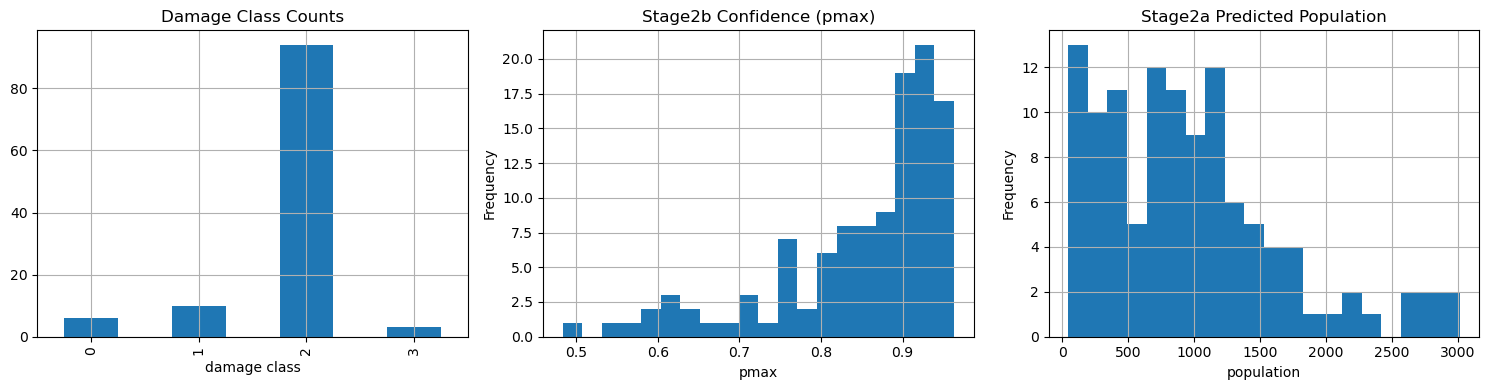

In [17]:
# --- 9) Distributional diagnostics ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if "stage2b_pred_damage_class" in df.columns:
    damage = df["stage2b_pred_damage_class"].astype(str)
    damage = damage[damage != ""]
    damage.value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Damage Class Counts")
    axes[0].set_xlabel("damage class")

if "stage2b_pmax" in df.columns:
    pd.to_numeric(df["stage2b_pmax"], errors="coerce").dropna().plot(kind="hist", bins=20, ax=axes[1], title="Stage2b Confidence (pmax)")
    axes[1].set_xlabel("pmax")

if "stage2a_pred_population" in df.columns:
    pd.to_numeric(df["stage2a_pred_population"], errors="coerce").dropna().plot(kind="hist", bins=20, ax=axes[2], title="Stage2a Predicted Population")
    axes[2].set_xlabel("population")

plt.tight_layout()
plt.show()

### Uncertainty Preview

Display the top uncertain instances and preview generated overlay images for qualitative review.

Top uncertain instances (first 20):


,instance_id,tile_id,stage2b_pred_damage_class,stage2b_pmax,stage2b_entropy,stage2b_var_expected_severity_weighted,stage1_sam3_confidence,stage2a_pred_population,stage2a_pred_type_class,stage2a_pred_type_conf
0,d0d2ea03-49b7-4484-b563-a71d7120f43e,nepal-flooding_00000408,2,0.626157,0.981120,0.088681,0.537324,2775.129395,commercial,0.850954
1,18a1747e-8673-44fa-acd8-d675284ed939,nepal-flooding_00000408,2,0.601902,0.967076,0.011287,0.727723,1144.960815,commercial,0.609732
2,a19b5594-fc36-4496-b9d8-3e221b3495fe,nepal-flooding_00000408,1,0.624434,0.924669,0.016329,0.558650,116.156059,institutional,0.523553
3,323a4e1b-31e5-4663-8ed0-871cd471fa11,nepal-flooding_00000408,2,0.642152,0.915487,0.118797,0.611485,1786.849121,commercial,0.761535
4,04b227df-6176-45a7-acfe-6a3034b9bb23,nepal-flooding_00000408,2,0.709753,0.886693,0.018746,0.503952,121.821358,institutional,0.596623
5,23269db7-eba6-45ba-89dc-0be27f315cb4,nepal-flooding_00000408,1,0.591081,0.857761,0.027348,0.699470,679.988403,commercial,0.517448
6,418fbe6e-6b3c-466c-97e1-740f350b0737,nepal-flooding_00000408,2,0.672722,0.854492,0.079666,0.643273,1094.192993,commercial,0.645065
7,6ca90a6f-fdcb-4965-8bb0-1a062540531d,nepal-flooding_00000408,2,0.537775,0.839967,0.087797,0.515266,1120.065308,commercial,0.791614
8,58d7d3e5-5c1e-4148-aec0-c5656045b92c,nepal-flooding_00000408,2,0.739302,0.839624,0.087020,0.711407,1216.048706,commercial,0.725024
9,c4ae776f-7287-4787-899a-e4d655e9dcd0,nepal-flooding_00000408,1,0.483375,0.834087,0.009041,0.775628,234.757294,commercial,0.495098


overlay files found: 100


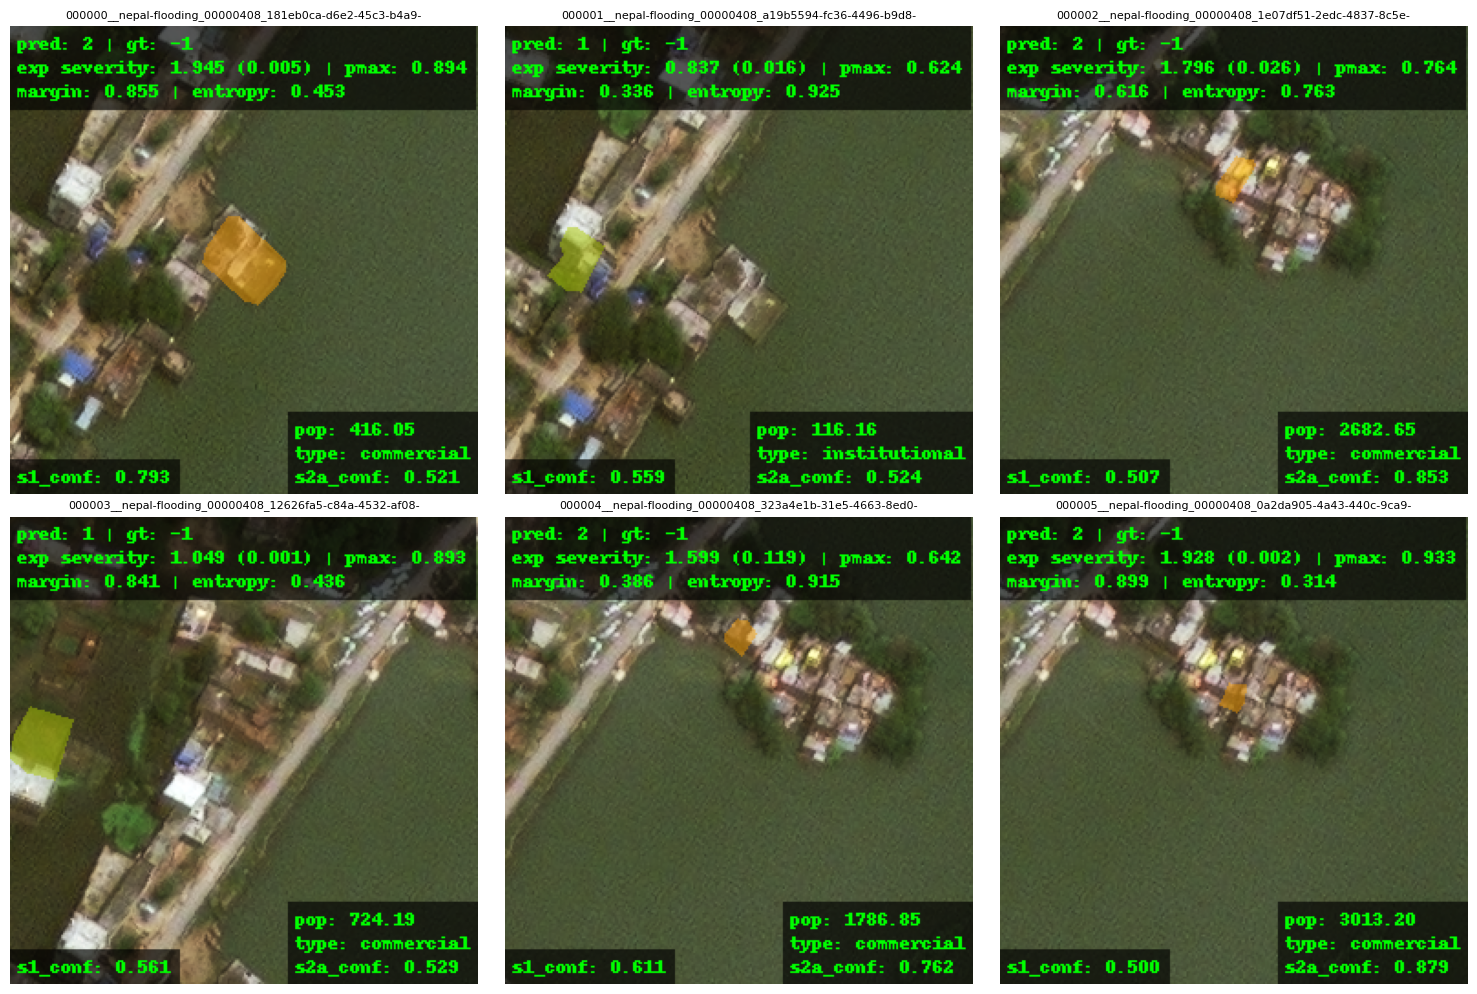

In [18]:
# --- 10) Uncertainty table + overlay preview ---
preview_cols = [
    "instance_id",
    "tile_id",
    "stage2b_pred_damage_class",
    "stage2b_pmax",
    "stage2b_entropy",
    "stage2b_var_expected_severity_weighted",
    "stage1_sam3_confidence",
    "stage2a_pred_population",
    "stage2a_pred_type_class",
    "stage2a_pred_type_conf",
]
cols = [c for c in preview_cols if c in df_unc.columns]
print("Top uncertain instances (first 20):")
display(df_unc[cols].head(20))

all_png = sorted(vis_dir.glob("*.png"))
assert len(all_png) > 0, f"No overlay images found in {vis_dir}"
img_paths = all_png[:6]
print("overlay files found:", len(all_png))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, p in zip(axes, img_paths):
    im = Image.open(p)
    ax.imshow(im)
    ax.set_title(p.name[:56], fontsize=8)
    ax.axis("off")
for ax in axes[len(img_paths):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8) Conclusion Template (for reports)

This case study demonstrates the full instance-impact pathway:

1. **Input**: paired pre/post imagery for a selected tile.
2. **Processing**: instance extraction and stage-wise inference executed end-to-end in this notebook.
3. **Outputs**: instance-level damage, exposure proxies, and uncertainty diagnostics.
4. **Interpretation**: uncertainty-ranked instances and overlay visual evidence support downstream triage.

For comparative studies, repeat with multiple `RUN_ID`s and aggregate the same summary statistics across tiles/events.